Dataset Shape: (50000, 21)
Features before PCA: 33

Explained Variance Ratio:
PC1: 0.2525
PC2: 0.0497

Total Variance Explained: 0.3023
Total Variance Explained (%): 30.23 %

PCA Data:


,PC1,PC2
0,-1.535424,2.013028
1,-2.658468,-0.991863
2,0.795501,2.040782
3,6.712990,2.074989
4,4.748633,1.831460


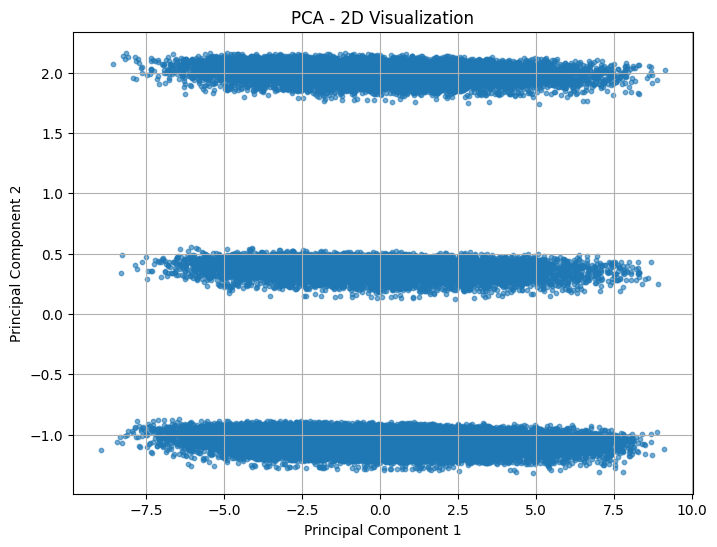

In [1]:
# ============================================================
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/placement_predict_50k_adjusted (1).csv")

print("Dataset Shape:", df.shape)

# ------------------------------------------------------------
# 2. Select Features
# ------------------------------------------------------------

numeric_cols = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

categorical_cols = [
    "Gender",
    "City",
    "CollegeTier",
    "Stream",
    "Specialisation",
    "Hostel",
    "HistoryOfBacklogs",
    "ExtraCurricular"
]

# ------------------------------------------------------------
# 3. Handle Missing Values
# ------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

num_data = pd.DataFrame(
    imputer.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

# ------------------------------------------------------------
# 4. Convert Categorical Variables
# ------------------------------------------------------------

cat_data = pd.get_dummies(
    df[categorical_cols],
    drop_first=True
)

features = pd.concat(
    [num_data, cat_data],
    axis=1
)

print("Features before PCA:", features.shape[1])

# ------------------------------------------------------------
# 5. Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X = scaler.fit_transform(features)

# ------------------------------------------------------------
# 6. Apply PCA
# ------------------------------------------------------------

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

# ------------------------------------------------------------
# 7. Explained Variance
# ------------------------------------------------------------

print("\nExplained Variance Ratio:")

print(
    "PC1:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "PC2:",
    round(pca.explained_variance_ratio_[1], 4)
)

total_variance = (
    pca.explained_variance_ratio_.sum()
)

print(
    "\nTotal Variance Explained:",
    round(total_variance, 4)
)

print(
    "Total Variance Explained (%):",
    round(total_variance * 100, 2),
    "%"
)

# ------------------------------------------------------------
# 8. Create PCA DataFrame
# ------------------------------------------------------------

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("\nPCA Data:")
display(pca_df.head())

# ------------------------------------------------------------
# 9. PCA Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=10,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA - 2D Visualization")

plt.grid(True)

plt.show()